In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

%matplotlib inline

sns.set_theme()

In [62]:
df = pd.read_csv('/content/loan_dataset.csv')
print(df.shape)
df.head()

(614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [63]:
#statistical measures
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [65]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [66]:
# dropping missing values becuase we can not fill categorical data(yes/no things) using mean values i.e. we can not use imputation method
# all those rows will be deleted who has any null value

df.dropna(inplace=True)
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [67]:
# Label Encoding needed because the loan_status that we are goin got predict is in Y/N format so we need to make it 0/1

df.replace({'Loan_Status':{'N':0, 'Y':1}}, inplace=True)
df['Loan_Status']

<ipython-input-67-b69bf16c96b2>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Loan_Status':{'N':0, 'Y':1}}, inplace=True)


,Loan_Status
1,0
2,1
3,1
4,1
5,1
...,...
609,1
610,1
611,1
612,1


In [68]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [69]:
df['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
3+,41


In [70]:
# replace the values 3+ with 4 because that is a string and other values are int i.e. 0,1,2

df.replace({'Dependents' :{'3+':4}}, inplace=True)
df['Dependents'].value_counts()

# we can also do df.replace(to_replace='3+', value=4)

,count
Dependents,
0,274
2,85
1,80
4,41


<Axes: xlabel='Education', ylabel='count'>

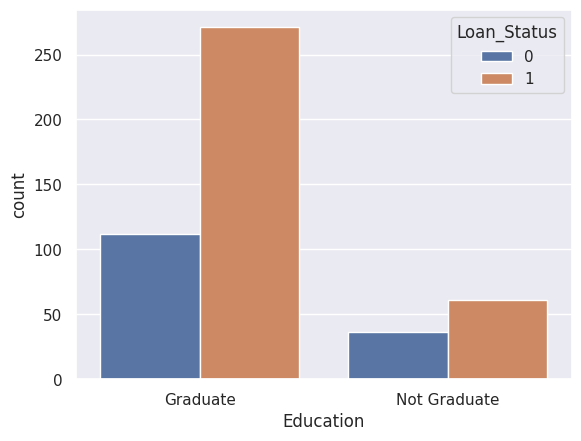

In [71]:
sns.countplot(data=df, x='Education', hue='Loan_Status')

<Axes: xlabel='Married', ylabel='count'>

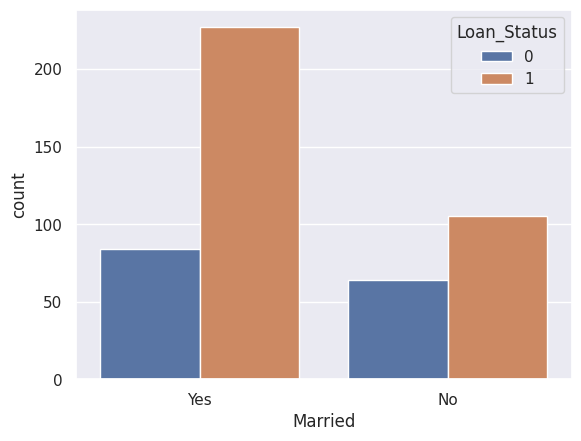

In [72]:
sns.countplot(data=df, x='Married', hue='Loan_Status')

In [73]:
# conerrt categorical column values to numerical

df.replace({"Married":{"Yes":1,"No":0},
            "Gender":{"Male":1,"Female":0},
            "Self_Employed":{"Yes":1, "No":0},
            "Property_Area":{"Rural":0,"Semiurban":1,     "Urban":2},
            "Education":{"Not Graduate":0, "Graduate":1}},inplace=True)

<ipython-input-73-2890ec5d4059>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Married":{"Yes":1,"No":0},


In [74]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


In [75]:
#seperating data and labels

x = df.drop(columns=['Loan_ID', "Loan_Status"], axis=1)
y = df['Loan_Status']

In [81]:
# train test split

xtrain,xtest,ytrain,ytest = train_test_split(x,y,
                                             test_size = 0.05,stratify = y,random_state=2)
print(x.shape,xtrain.shape,xtest.shape)

(480, 11) (456, 11) (24, 11)


In [82]:
# Model is SVM model

classifier = svm.SVC(kernel='linear')

# training
classifier.fit(xtrain,ytrain)



SVC(kernel='linear')

Example of SVM model :

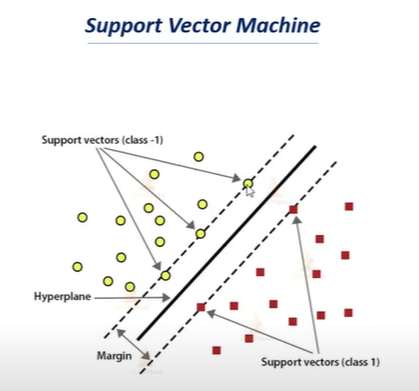

In [78]:
# model evaluation
# accuracy on trainning data
xtrain_prediction = classifier.predict(xtrain)
training_data_accuracy = accuracy_score(xtrain_prediction,ytrain)
print('Accuracy score of the training data : ',training_data_accuracy)

Accuracy score of the training data :  0.7786458333333334


In [79]:
# accuracy on testing data
xtest_prediction = classifier.predict(xtest)
testing_data_accuracy = accuracy_score(xtest_prediction,ytest)
print('Accuracy score of the testing data : ',testing_data_accuracy)

Accuracy score of the testing data :  0.8125


In [80]:
# creating a prediction system
input_data = (1,	1,	1,	1,	0,	4583,	1508.0,	128.0,	360.0,	1.0,	0		)

# converting into np array
inpdata = np.asarray(input_data)

# reshaping because we're only prediction for 1 person's data
inpdata_reshaped = inpdata.reshape(1,-1)

prediction = classifier.predict(inpdata_reshaped)
print(prediction)


[1]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
